In [1]:
import os
from tqdm.auto import tqdm
import pandas as pd

import geopandas as gpd
import pycountry

import matplotlib.pyplot as plt
import matplotlib.dates as mdates

import requests
import zipfile

pd.options.mode.chained_assignment = (
    None  # default='warn' This disables warning of "copying a slice of a DataFrame"
)
tqdm.pandas()  # activate the tqdm for pandas

In [2]:
from utils.set_paths import (
    path_figs,
    path_data,
    path_output,
)

In [3]:
summary_excel = pd.read_excel("../EconJM_status.xlsx", sheet_name="sum")
summary_excel.tail(5)

,add_id,s,app_notes,deadline_target,add_posting,add_how_apply,good_match,recruitment_officer,app_status,outcome,...,location,country,add_rank,add_field,add_category,review_deadline,other_link,need_cover_letter,need_RS,need_TS
278,torino_post,NaN,NaN,2026-02-01,EJM,NaN,NaN,NaN,completed,no news,...,NaN,Italy,postdoc,NaN,research,2026-03-01,NaN,1.0,0.0,0.0
279,st_luis,NaN,NaN,2026-02-01,EJM,NaN,NaN,NaN,completed,no news,...,NaN,United States,assistant,NaN,research,2026-03-15,NaN,1.0,0.0,0.0
280,boston_2,NaN,NaN,2026-02-01,EJM,NaN,NaN,NaN,completed,no news,...,NaN,United States,assistant,NaN,research,2026-02-15,NaN,1.0,0.0,0.0
281,zurich_post_dig,NaN,NaN,2026-02-01,EJM,NaN,NaN,NaN,completed,no news,...,NaN,Switzerland,postdoc,NaN,research,2026-02-01,NaN,1.0,0.0,0.0
282,andres_bello,NaN,NaN,2026-02-01,JOE,https://www.aeaweb.org/joe/listing.php?JOE_ID=...,NaN,NaN,completed,no news,...,NaN,Chile,assistant,NaN,research,2026-02-01,NaN,1.0,0.0,0.0


In [4]:
# add the country iso3 codes 
def get_iso3(country_name):

    try:
        c_name = pycountry.countries.search_fuzzy(country_name)
        # print(c_name)
        
        return c_name[0].alpha_3
    except LookupError:
        # print(f"Country not found: {country_name}")
        return None

In [5]:
summary_excel['iso3'] = summary_excel['country'].apply(get_iso3)
summary_excel.tail(5)

,add_id,s,app_notes,deadline_target,add_posting,add_how_apply,good_match,recruitment_officer,app_status,outcome,...,country,add_rank,add_field,add_category,review_deadline,other_link,need_cover_letter,need_RS,need_TS,iso3
278,torino_post,NaN,NaN,2026-02-01,EJM,NaN,NaN,NaN,completed,no news,...,Italy,postdoc,NaN,research,2026-03-01,NaN,1.0,0.0,0.0,ITA
279,st_luis,NaN,NaN,2026-02-01,EJM,NaN,NaN,NaN,completed,no news,...,United States,assistant,NaN,research,2026-03-15,NaN,1.0,0.0,0.0,USA
280,boston_2,NaN,NaN,2026-02-01,EJM,NaN,NaN,NaN,completed,no news,...,United States,assistant,NaN,research,2026-02-15,NaN,1.0,0.0,0.0,USA
281,zurich_post_dig,NaN,NaN,2026-02-01,EJM,NaN,NaN,NaN,completed,no news,...,Switzerland,postdoc,NaN,research,2026-02-01,NaN,1.0,0.0,0.0,CHE
282,andres_bello,NaN,NaN,2026-02-01,JOE,https://www.aeaweb.org/joe/listing.php?JOE_ID=...,NaN,NaN,completed,no news,...,Chile,assistant,NaN,research,2026-02-01,NaN,1.0,0.0,0.0,CHL


In [6]:
region_codes = pd.read_csv("iso_with_region_codes.csv")
region_codes = region_codes[['alpha-3', 'region', 'region-code']]

summary_excel = summary_excel.merge(region_codes, left_on='iso3', right_on='alpha-3', how='left')
summary_excel.tail(5)

,add_id,s,app_notes,deadline_target,add_posting,add_how_apply,good_match,recruitment_officer,app_status,outcome,...,add_category,review_deadline,other_link,need_cover_letter,need_RS,need_TS,iso3,alpha-3,region,region-code
278,torino_post,NaN,NaN,2026-02-01,EJM,NaN,NaN,NaN,completed,no news,...,research,2026-03-01,NaN,1.0,0.0,0.0,ITA,ITA,Europe,150.0
279,st_luis,NaN,NaN,2026-02-01,EJM,NaN,NaN,NaN,completed,no news,...,research,2026-03-15,NaN,1.0,0.0,0.0,USA,USA,Americas,19.0
280,boston_2,NaN,NaN,2026-02-01,EJM,NaN,NaN,NaN,completed,no news,...,research,2026-02-15,NaN,1.0,0.0,0.0,USA,USA,Americas,19.0
281,zurich_post_dig,NaN,NaN,2026-02-01,EJM,NaN,NaN,NaN,completed,no news,...,research,2026-02-01,NaN,1.0,0.0,0.0,CHE,CHE,Europe,150.0
282,andres_bello,NaN,NaN,2026-02-01,JOE,https://www.aeaweb.org/joe/listing.php?JOE_ID=...,NaN,NaN,completed,no news,...,research,2026-02-01,NaN,1.0,0.0,0.0,CHL,CHL,Americas,19.0


In [7]:
summary_timeline = pd.read_excel("../EconJM_status.xlsx", sheet_name="timeline")
summary_timeline.tail(5)

,date,app_id,comment
341,2026-02-03,zurich_post_dig,interview
342,2026-02-03,berry_2,rejected
343,2026-02-05,gigas,rejected
344,2026-02-05,getty,rejected
345,2026-02-05,andres_bello,app sent


In [8]:
# download the world map
url = "https://naturalearth.s3.amazonaws.com/110m_cultural/ne_110m_admin_0_countries.zip"
dest_dir = path_data / "naturalearth_110m"
zip_path = dest_dir / "ne_110m_admin_0_countries.zip"

dest_dir.mkdir(parents=True, exist_ok=True)
if not zip_path.exists():
    with requests.get(url, stream=True) as r:
        r.raise_for_status()
        with open(zip_path, "wb") as f:
            for chunk in r.iter_content(chunk_size=8192):
                if chunk:
                    f.write(chunk)

with zipfile.ZipFile(zip_path, "r") as z:
    z.extractall(dest_dir)

shp_path = dest_dir / "ne_110m_admin_0_countries.shp"
gdf_ne = gpd.read_file(shp_path)

# optional: filter out Antarctica
gdf_ne = gdf_ne[gdf_ne["NAME"] != "Antarctica"]


# also correct FRANCE ISO_A3 code
gdf_ne.loc[43, 'ISO_A3'] = 'FRA'

# apps descriptives

In [9]:
summary_excel['add_rank'].value_counts(dropna=False)

add_rank
assistant     202
postdoc        48
NaN            24
lecturer        3
teaching        3
adjunct         1
fellowship      1
visiting        1
Name: count, dtype: int64

# Geo Distribution of Applications

In [10]:
apps_by_iso = (
    summary_excel
    .groupby("iso3", dropna=False)
    .agg(n_apps=("iso3", "size"),
         region=("region", "first"),
         region_code=("region-code", "first"))
    .reset_index()
    .sort_values("n_apps", ascending=False)
)

bins = [0, 1, 2, 3, 4, 9, 15, float('inf')]
labels = ['1', '2', '3', '4', '5-9', '10-15', '100+']
apps_by_iso['n_apps_bin'] = pd.cut(apps_by_iso['n_apps'], bins=bins, labels=labels, right=True, include_lowest=True)

apps_by_iso.head()

,iso3,n_apps,region,region_code,n_apps_bin
30,USA,120,Americas,19.0,100+
14,FRA,15,Europe,150.0,10-15
12,ESP,14,Europe,150.0,10-15
10,DEU,13,Europe,150.0,10-15
17,ITA,11,Europe,150.0,10-15


In [11]:
geo_apps = gdf_ne.merge(apps_by_iso, left_on='ISO_A3', right_on='iso3', how='left')

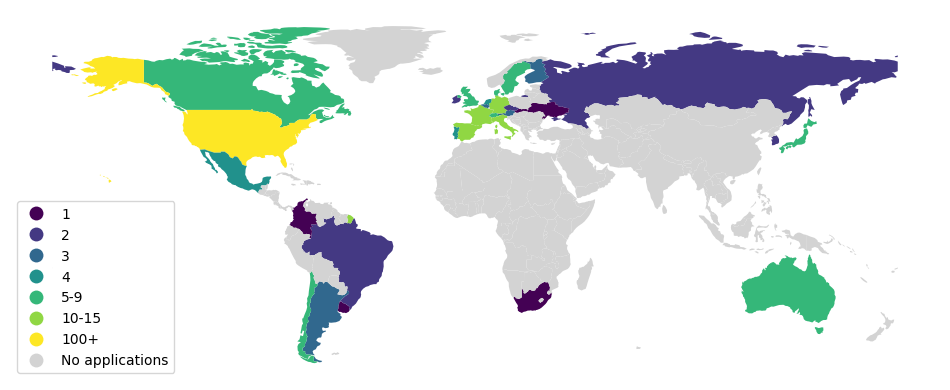

In [12]:
ax = geo_apps.plot(
    column='n_apps_bin',
    cmap='viridis',
    legend=True,
    figsize=(12, 9),
    missing_kwds={"color": "lightgrey", "label": "No applications"}
)
ax.set_axis_off()
leg = ax.get_legend()
if leg is not None:
    leg.set_loc('lower left')

out_path = path_figs / "geo_apps.png"
ax.figure.savefig(out_path, bbox_inches='tight', dpi=300)

In [13]:
apps_by_region = (
    apps_by_iso
    .dropna(subset=['region'])
    .groupby('region', as_index=False)
    .agg(n_apps=('n_apps', 'sum'))
    .sort_values('n_apps', ascending=False)
)

total_apps = apps_by_region['n_apps'].sum()
apps_by_region['share'] = apps_by_region['n_apps'] / total_apps

apps_by_region = pd.concat(
    [apps_by_region, pd.DataFrame([{'region': 'Total', 'n_apps': total_apps, 'share': 1.0}])],
    ignore_index=True
)

apps_by_region

,region,n_apps,share
0,Americas,145,0.517857
1,Europe,114,0.407143
2,Asia,13,0.046429
3,Oceania,7,0.025000
4,Africa,1,0.003571
5,Total,280,1.000000


# Cumm. Applications + hear back

In [14]:
mask = summary_timeline['comment'].str.contains(r'\b(?:app sent|rejected|interview|fly out)\b', case=False, na=False)
summary_timeline = summary_timeline[mask].reset_index(drop=True)
summary_timeline

,date,app_id,comment
0,2025-10-14,simon_frazer_1,app sent
1,2025-10-14,macmaster_1,app sent
2,2025-10-15,rovira_1,app sent
3,2025-10-16,american_u_1,app sent
4,2025-10-16,analysis_1,app sent
...,...,...,...
313,2026-02-03,zurich_post_dig,interview
314,2026-02-03,berry_2,rejected
315,2026-02-05,gigas,rejected
316,2026-02-05,getty,rejected


In [15]:
apps_sents_timeline = summary_timeline[summary_timeline['comment'].str.contains(r'\bapp sent\b', case=False, na=False)].copy()
apps_by_date = (
    apps_sents_timeline
    .groupby('date', as_index=False)
    .agg(n_apps=('app_id', 'size'))
    .sort_values('date')
)
apps_by_date["cumsum_apps"] = apps_by_date['n_apps'].cumsum()
apps_by_date.head()

,date,n_apps,cumsum_apps
0,2025-10-14,2,2
1,2025-10-15,1,3
2,2025-10-16,5,8
3,2025-10-17,10,18
4,2025-10-18,8,26


In [16]:
top5_deadlines = summary_excel['deadline_target'].dropna().value_counts().head(5).sort_index().index.tolist()
top5_deadlines

[Timestamp('2025-10-25 00:00:00'),
 Timestamp('2025-11-05 00:00:00'),
 Timestamp('2025-11-10 00:00:00'),
 Timestamp('2025-11-20 00:00:00'),
 Timestamp('2026-01-01 00:00:00')]

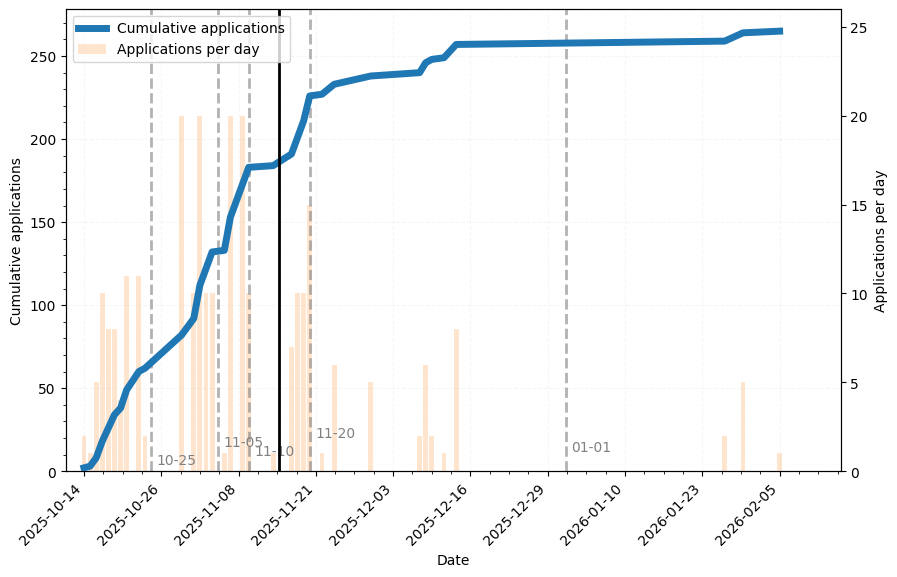

In [17]:
fig, ax = plt.subplots(figsize=(10, 6))
# plot cumulative line
ax.plot(
    apps_by_date['date'],
    apps_by_date['cumsum_apps'],
    # marker='o',
    linestyle='-',
    linewidth=5,
    # markersize=10,
    # markeredgewidth=1,
    color='C0',
    zorder=3,
    label='Cumulative applications'
)

# secondary axis for daily applications (bars) placed in background
ax2 = ax.twinx()
ax.set_zorder(1)
ax.patch.set_visible(False)
ax2.set_zorder(0)
ax2.patch.set_visible(False)

ax2.bar(
    apps_by_date['date'],
    apps_by_date['n_apps'],
    width=pd.Timedelta(days=0.8),
    color='C1',
    alpha=0.2,
    zorder=0,
    label='Applications per day'
)
ax2.set_ylabel('Applications per day')

ax.set_xlabel('Date')
ax.set_ylabel('Cumulative applications')

# grid tweaks
ax.grid(which='major', linestyle='--', linewidth=0.8, alpha=0.1)
ax.minorticks_on()
ax.grid(which='minor', linestyle=':', linewidth=0.5, alpha=0.05)

# set evenly spaced x-ticks
n_ticks = min(10, len(apps_by_date))
ticks = pd.date_range(apps_by_date['date'].min(), apps_by_date['date'].max(), periods=n_ticks)
ax.set_xticks(ticks)
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d'))
plt.setp(ax.get_xticklabels(), rotation=45, ha='right')

# extend x-limits by a few days
ax.set_xlim(apps_by_date['date'].min() - pd.Timedelta(days=3),
            apps_by_date['date'].max() + pd.Timedelta(days=10))

# adjust y-limits
ax.set_ylim(0, apps_by_date['cumsum_apps'].max() * 1.05)
ax2.set_ylim(0, apps_by_date['n_apps'].max() * 1.3)

# add vertical lines and staggered annotations for top deadlines
ymin, ymax = ax.get_ylim()
yrange = ymax - ymin
offsets = [0.02, 0.06, 0.04, 0.08, 0.05]
for i, dd in enumerate(top5_deadlines):
    ax.axvline(dd, color='grey', linestyle='--', linewidth=2, alpha=0.6, zorder=2)
    y = ymin + offsets[i % len(offsets)] * yrange
    ax.annotate(
        dd.strftime('%m-%d'),
        xy=(dd, y),
        xytext=(4, 1),
        textcoords='offset points',
        ha='left',
        va='center',
        color='grey',
        fontsize=10,
        zorder=4
    )

# Add solid black vertical line at 2025-11-15
ax.axvline(pd.Timestamp('2025-11-15'), color='black', linestyle='-', linewidth=2, zorder=4)

# combined legend
lines, labels = ax.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax.legend(lines + lines2, labels + labels2, loc='upper left')

out_path = path_figs / "cumsum_apps.png"
fig.savefig(out_path, bbox_inches='tight', dpi=300)
# fig

In [18]:
# fig, ax = plt.subplots(figsize=(10, 6))
# ax.bar(
#     apps_by_date['date'],
#     apps_by_date['n_apps'],
#     width=pd.Timedelta(days=0.8),
#     align='center',
#     color='C0',
#     zorder=2
# )
# ax.set_xlabel('Date')
# ax.set_ylabel('Applications per day')

# # grid tweaks
# ax.grid(which='major', linestyle='--', linewidth=0.8, alpha=0.1)
# ax.minorticks_on()
# ax.grid(which='minor', linestyle=':', linewidth=0.5, alpha=0.05)

# # set x-ticks
# ax.set_xticks(ticks)
# ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d'))
# plt.setp(ax.get_xticklabels(), rotation=45, ha='right')

# # extend x-limits
# ax.set_xlim(apps_by_date['date'].min() - pd.Timedelta(days=3),
#             apps_by_date['date'].max() + pd.Timedelta(days=10))

# # add vertical lines and staggered annotations for top deadlines
# ymin = 0
# ymax = apps_by_date['n_apps'].max() * 1.2
# ax.set_ylim(ymin, ymax)
# yrange = ymax - ymin
# offsets = [0.02, 0.06, 0.04, 0.08, 0.05]
# for i, dd in enumerate(top5_deadlines):
#     ax.axvline(dd, color='grey', linestyle='--', linewidth=2, alpha=0.6, zorder=1)
#     y = ymin + offsets[i % len(offsets)] * yrange
#     # ax.annotate(
#     #     dd.strftime('%m-%d'),
#     #     xy=(dd, y),
#     #     xytext=(2, 1),
#     #     textcoords='offset points',
#     #     ha='left',
#     #     va='center',
#     #     color='grey',
#     #     fontsize=10,
#     #     zorder=3
#     # )

# # Add solid black vertical line at 2025-11-15
# ax.axvline(pd.Timestamp('2025-11-15'), color='black', linestyle='-', linewidth=2, zorder=2)

# out_path = path_figs / "apps_per_day.png"
# fig.savefig(out_path, bbox_inches='tight', dpi=300)


# Results from apps by week

In [19]:
summary_timeline['week_start'] = summary_timeline['date'] - pd.to_timedelta(summary_timeline['date'].dt.weekday, unit='D')
min_week = summary_timeline['week_start'].min()
max_week = summary_timeline['week_start'].max()
unique_week_starts = pd.Series(pd.date_range(start=min_week, end=max_week, freq='7D'), name='week_start')
unique_week_starts

0    2025-10-13
1    2025-10-20
2    2025-10-27
3    2025-11-03
4    2025-11-10
5    2025-11-17
6    2025-11-24
7    2025-12-01
8    2025-12-08
9    2025-12-15
10   2025-12-22
11   2025-12-29
12   2026-01-05
13   2026-01-12
14   2026-01-19
15   2026-01-26
16   2026-02-02
Name: week_start, dtype: datetime64[ns]

In [20]:
apps_results = summary_timeline[~summary_timeline['comment'].str.contains(r'\bapp sent\b', case=False, na=False)].copy()
apps_results['week_start'] = apps_results['date'] - pd.to_timedelta(apps_results['date'].dt.weekday, unit='D')
apps_results

,date,app_id,comment,week_start
226,2025-11-22,cna,rejected,2025-11-17
229,2025-11-24,leibniz,rejected,2025-11-24
235,2025-11-29,tcu,rejected,2025-11-24
236,2025-11-28,uandes_col,interview,2025-11-24
242,2025-12-01,a_paris,rejected,2025-12-01
243,2025-12-02,palm_beach,rejected,2025-12-01
244,2025-12-02,givewell,rejected,2025-12-01
245,2025-12-04,bank_itl,rejected,2025-12-01
246,2025-12-04,unsw_post,interview,2025-12-01
247,2025-12-07,safrica,interview,2025-12-01


In [21]:
total_no_news = summary_excel.shape[0]

In [22]:
# Initialize lists to store weekly counts
weeks = unique_week_starts
no_news = []
rejects = []
interviews = []
fly_outs = []
offers = []

# Initial values
current_no_news = total_no_news
current_reject = 0
current_interview = 0
current_fly_out = 0
current_offer = 0

# Sort weeks and results
weeks = weeks.sort_values()
apps_results_sorted = apps_results.sort_values('date')

# For each week, update the counts
for week in weeks:
    # Filter results up to and including this week
    week_results = apps_results_sorted[apps_results_sorted['week_start'] == week]
    for _, row in week_results.iterrows():
        comment = row['comment'].lower()
        if 'rejected' in comment:
            current_no_news -= 1
            current_reject += 1
        elif 'interview' in comment:
            current_no_news -= 1
            current_interview += 1
        elif 'fly out' in comment:
            current_fly_out += 1
            current_interview -= 1  # Remove from interview count
        elif 'offer' in comment:
            current_fly_out -= 1
            current_offer += 1

    no_news.append(current_no_news)
    rejects.append(current_reject)
    interviews.append(current_interview)
    fly_outs.append(current_fly_out)
    offers.append(current_offer)

# Create a DataFrame with the results
weekly_status = pd.DataFrame({
    'week_start': weeks,
    'no_news': no_news,
    'rejects': rejects,
    'interviews': interviews,
    'fly_outs': fly_outs,
    'offers': offers
})
weekly_status

,week_start,no_news,rejects,interviews,fly_outs,offers
0,2025-10-13,283,0,0,0,0
1,2025-10-20,283,0,0,0,0
2,2025-10-27,283,0,0,0,0
3,2025-11-03,283,0,0,0,0
4,2025-11-10,283,0,0,0,0
5,2025-11-17,282,1,0,0,0
6,2025-11-24,279,3,1,0,0
7,2025-12-01,273,7,3,0,0
8,2025-12-08,267,11,4,1,0
9,2025-12-15,260,17,4,2,0


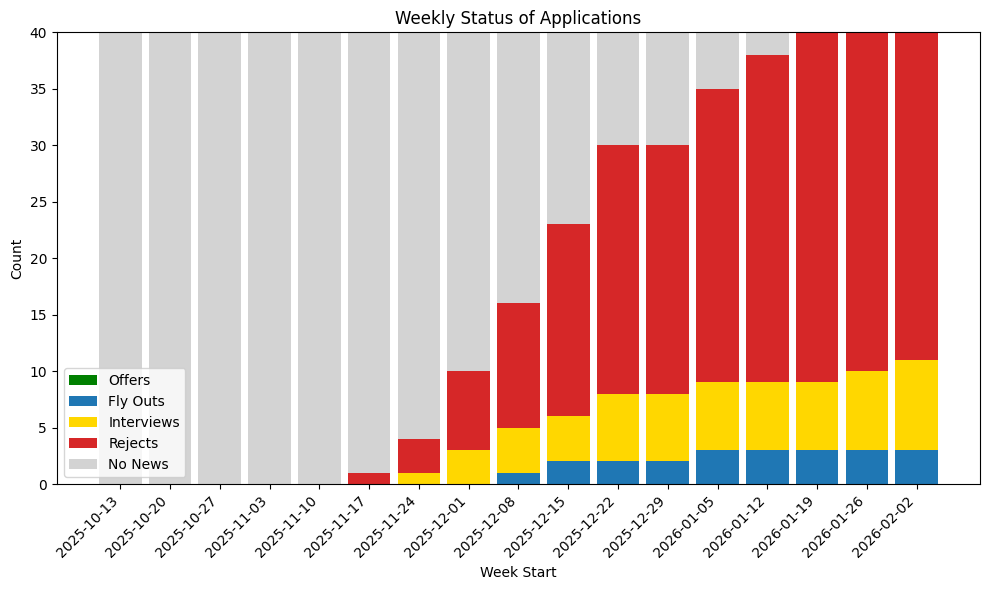

In [23]:
fig, ax = plt.subplots(figsize=(10, 6))

# Plot stacked bars in the order: offers (bottom, green), fly_outs, interviews, rejects, no_news (top)
ax.bar(
    weekly_status['week_start'],
    weekly_status['offers'],
    width=6,
    label='Offers',
    color='green'
)
ax.bar(
    weekly_status['week_start'],
    weekly_status['fly_outs'],
    width=6,
    bottom=weekly_status['offers'],
    label='Fly Outs',
    color='tab:blue'
)
ax.bar(
    weekly_status['week_start'],
    weekly_status['interviews'],
    width=6,
    bottom=weekly_status['offers'] + weekly_status['fly_outs'],
    label='Interviews',
    color='gold'
)
ax.bar(
    weekly_status['week_start'],
    weekly_status['rejects'],
    width=6,
    bottom=weekly_status['offers'] + weekly_status['fly_outs'] + weekly_status['interviews'],
    label='Rejects',
    color='tab:red'
)
ax.bar(
    weekly_status['week_start'],
    weekly_status['no_news'],
    width=6,
    bottom=weekly_status['offers'] + weekly_status['fly_outs'] + weekly_status['interviews'] + weekly_status['rejects'],
    label='No News',
    color='lightgrey'
)

ax.set_xlabel('Week Start')
ax.set_ylabel('Count')
ax.set_title('Weekly Status of Applications')
ax.set_ylim(0, 40)
ax.legend()
ax.set_xticks(weekly_status['week_start'])
ax.set_xticklabels(weekly_status['week_start'].dt.strftime('%Y-%m-%d'), rotation=45, ha='right')

ax.legend(loc='lower left')


plt.tight_layout()
out_path = path_figs / "weekly_status.png"
fig.savefig(out_path, bbox_inches='tight', dpi=300)